**Lab 4: FIR filters and envelopes**

The goal of this lab is to learn how to implement FIR filters in Python, and how we can use them to improve our synthesis.

In [13]:
import os
import numpy as np
import librosa
import IPython.display as ipd
from scipy import signal
import matplotlib.pyplot as plt
from IPython.display import Audio

from util import load_audio, plot_signals, plot_spectrogram, plot_mean_spectrogram

**1. Overview of Filtering**

For this lab, we will define an FIR filter as a discrete-time system that converts an input signal $x[n]$ into an output signal $y[n]$ by means of the weighted summation:

$$
y[n] = \sum_{k=0}^M b_kx[n-k]
$$

The function *np.convolve()* is a generic function with which to implement FIR filters. The following code implements a three-point averaging system:

In [14]:
fs = 1
x = [np.floor(x/10) for x in range(50)]
b = np.array([1.0/3, 1.0/3, 1.0/3])
y = np.convolve(b, x)

plot_signals([x, y], fs, name=['input x[n]', 'output y[n]'], mode='lines+markers')

1.1 Explain the filtering action of the 5-point averager by comparing the plot of the input $x[n]$ and the output $y[n]$. This filter might be called a “smoothing” filter. Note how the transitions from one level to another have been “smoothed.”

The 5-point averager, is used to smooth or average a signal. It operates by averaging the current sample and four previous samples from the input signal to create a smoother output. This filtering action reduces the impact of high-frequency noise and sharp transitions in the input. We can see this from the example above by noteching how the transitions last longer and have less of an angle of attack. It's an overall smoother graphic than the blue one.

**El senyal d'entrada x[n] és un gràfic de forma escalonada. El senyal de sortida y[n], tot i que també puja de forma escalonada, ho fa més lentament, això vol dir que el sistema suavitza la resposta, de manera que el canvi és progressiu i no de cop.** 
**Aquest fet passa perquè el 5-point averager calcula la mitjana de la mostra actual amb les quatre anteriors, per tant cada valor de y[n] depèn tant de la mostra actual com de les anteriors.**

*1.2* Define a function `averaging_filter(x, N)` which implements the N-points averaging filter using the `np.convolve` function.

In [15]:
import numpy as np

def averaging_filter(x, N):
    """
    Applies a N-point averaging filter to the input signal x

    Parameters
    ----------
    x : np.array
        The input signal in the form of a numpy array
    N : int
        The number of points used in N-point averaging filter

    Returns
    -------
    y : np.array
        The output of the filter
    """

    # Vector de coeficients del filtre
    b = np.ones(N) / N

    # Aplicació de la convolució
    y = np.convolve(b, x)

    return y


1.3 Run the example above using the `averaging_filter` instead. Change the number N to different values and explain what happen.

In [16]:
fs = 1
x = [np.floor(x/10) for x in range(50)]

b = np.array([1.0/3, 1.0/3, 1.0/3])

N = 5
y = averaging_filter(x, N)

plot_signals([x, y], fs, name=['input x[n]', 'output y[n]'], mode='lines+markers')

**La funció averaging_filter(x, N) aplica un filtre el qual agafa N valors propers de la senyal d'entrada i calcula la seva mitjana, creant la senyal de sortida.**
**Si la N és petita, la senyal és escalonada, molt similar a la senyal d'entrada. A mesura que augmentem N, la senyal es va suavitzant. Tot i això, si N pren nombres molt elevats (més que la longitud de la senyal), la senyal de sortida s'aplana i visualment tendeix a valors propers a 0.**

1.4 How would you classify this filter, as a low-pass o high-pass filter?

**El que fa averaging_filter és suavitzar la senyal d'entrada fent la mitjana de valors propers, eliminant canvis sobtats. Podem observar en el gràfic, on les transicions brusques són més graduals, per tant, podem dir que és un filtre low-pass.**

---

**2. Envelope detector**

Now we'll implement an envelope detector by concatenating two systems: a full-wave rectifier (absolute value) and the N-point averaging filter.

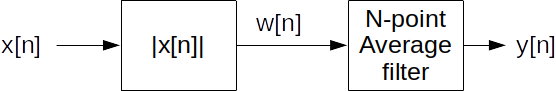

2.1 Define a function `envelope(x, N)` which applies an N-point averaging filter to the full-wave rectified signal and returns the output $y[n]$.

**Note 1**: to calculate the full-wave rectified signal check the `np.abs()` function.

**Note 2**: The output should have the same length as the input signal. Use 'same' mode (see [np.convolve](https://numpy.org/doc/stable/reference/generated/numpy.convolve.html) documentation).

In [ ]:
import numpy as np

def envelope(x, N):
    """
    Extracts the envelope of the input signal x by concatenating a full-wave rectifier and an N-point averaging filter.

    Parameters
    ----------
    x : np.array
        The input signal in the form of a numpy array
    N : int
        The number of points used in N-point averaging filter

    Returns
    -------
    y : np.array
        The output of the system, i.e., the envelope of the signal x.
    """
    # 1. Rectificador (valor absolut)
    x_rect = np.abs(x)

    # 2. N-point averaging filter (filtre de promig N punts)
    b = np.ones(N) / N  # Coeficients del filtre bk
    y = np.convolve(b, x_rect, mode='same')

    return y


2.2 Load your reference signal and calculate its envelope using the function you designed. Plot the reference signal and envelope in the same figure.

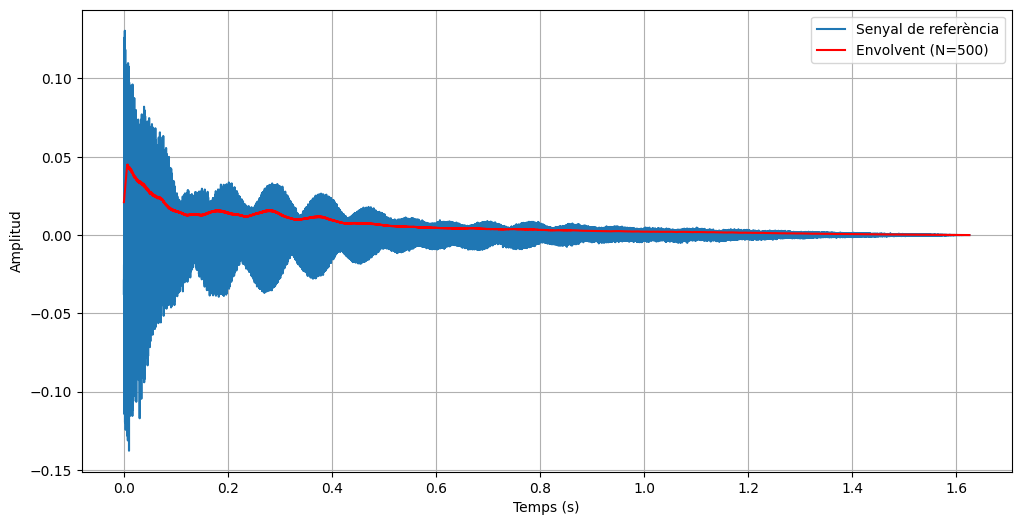

In [18]:
ref, fs = load_audio('audio/reference.wav')
ipd.Audio(ref, rate=fs)

# Calcular l'envolupant amb un valor inicial N
N = 500
env = envelope(ref, N)

# Crear un vector de temps per representar el senyal al llarg de temps (eix x)
t_ref = np.arange(len(ref)) / fs
t_env = np.arange(len(env)) / fs

# Plotear del senyal de referència i l'envolvent
plt.figure(figsize=(12, 6))
plt.plot(t_ref, ref, label='Senyal de referència')
plt.plot(t_env, env, label=f'Envolvent (N={N})', color='red')
plt.xlabel('Temps (s)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)
plt.show()

2.3 Change the number N to get a good result. What happens when you change the number N?

**L'envolvent ens indica com varia l'amplitud del senyal a estudiar al llarg del temps. El comportament d'aquest depèn de N en els següents casos:** 
- N petit: l'envolvent té molt de soroll i no se suavitza, per tant no captura correctament la forma general de l'amplitud.
- N òptim (ni molt gran, ni molt petit, 1000, per exemple): l'envolvent és suau i marca els canvis d'amplitud, és el valor ideal.
- N gran: l'envolvent s'aplana i tendeix a 0.

2.4 Explain with your own words why this system achieves extracting the envelope. It might be useful to plot together the signals $x[n]$, $w[n]$ and $y[n]$.

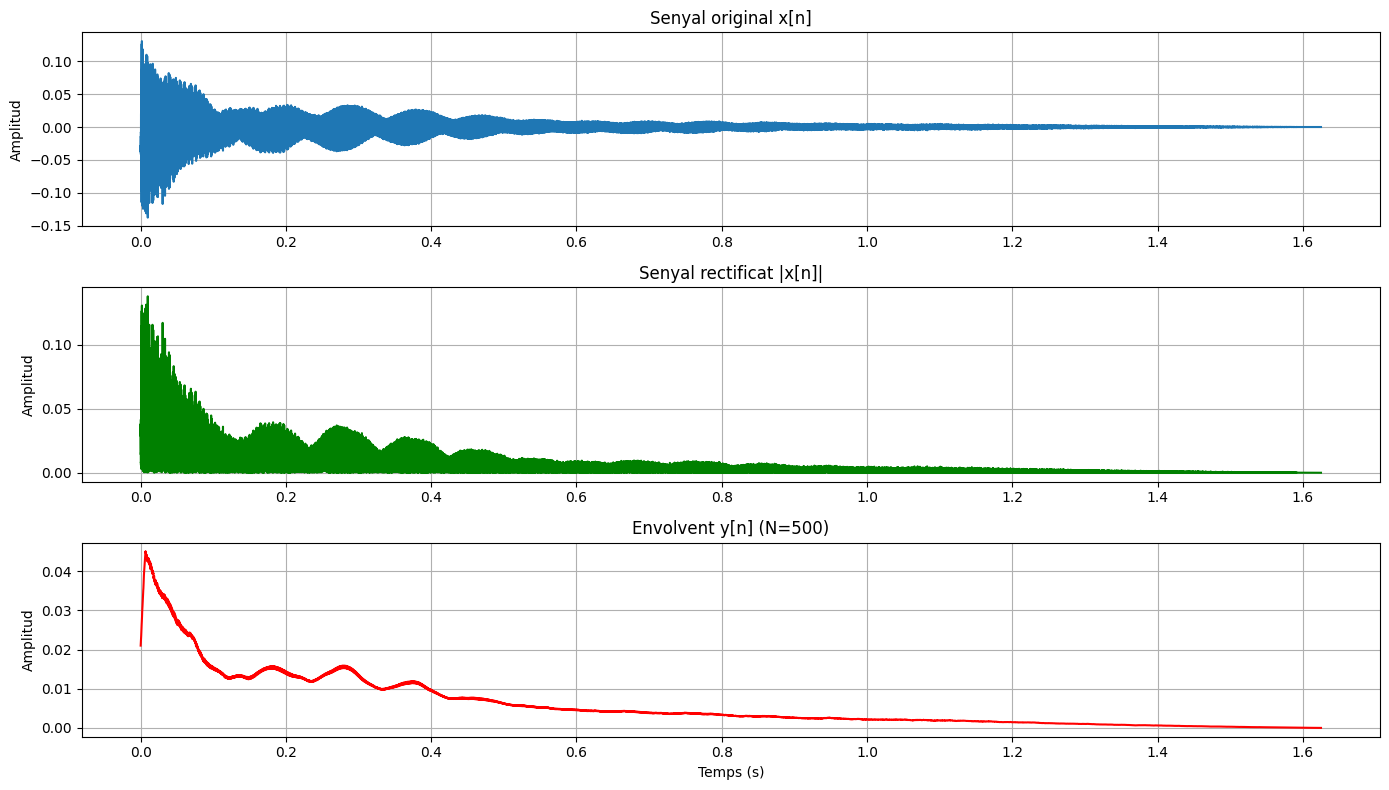

In [19]:
# Calcular les senyals intermèdies
N = 500
x_rect = np.abs(ref)    # Senyal rectificada (valor absolut)
env = envelope(ref, N)  # Envolvent y[n]

# Vectors de temps (per l'eix x)
t = np.arange(len(ref)) / fs

# Plot dels tres senyals
plt.figure(figsize=(14, 8))

# Senyal original x[n]
plt.subplot(3, 1, 1)
plt.plot(t, ref)
plt.ylabel('Amplitud')
plt.title('Senyal original x[n]')
plt.grid(True)

# Senyal rectificat (abs.) |x[n]|
plt.subplot(3, 1, 2)
plt.plot(t, x_rect, color='green')
plt.ylabel('Amplitud')
plt.title('Senyal rectificat |x[n]|')
plt.grid(True)

# Envolvent y[n]
plt.subplot(3, 1, 3)
plt.plot(t, env, color='red')
plt.ylabel('Amplitud')
plt.xlabel('Temps (s)')
plt.title(f'Envolvent y[n] (N={N})')
plt.grid(True)
plt.tight_layout() 
plt.show()

**Aquest sistema aconsegueix extreure l'envolvent mitjançant dos processos:**
- Rectificació: quan s'aplica el valor absolut, tots els valors negatius passen a ser positius. Això permet que les oscil·lacions estiguin per sobre del 0 creant un senyal sempre positiu que segueix els pics de l'amplitud.
- Averaging filter: aquest filtre suavitza el senyal rectificat i elimina les oscil·lacions ràpides, mantenint només les variacions lentes de l'amplitud, perquè el resultat sigui una corba suau que segueix els màxims del senyal original.

2.5 Now let's apply this envelope to the synthesized signal. Copy the code from Lab3 Ex. 2.1 and generate the synthesized signal. Then multiply the synthesized signal by the envelope. Note that both signal and envelope should have the same length. You can define a time vector of the same length of the envelope to create the signal:

In [20]:
# Els pesos estan calculats en els pics visibles del senyal
weights = [1, 0.55944, 0.07856, 0.06199, 0.1524, 0.04914, 0.04642, 0.02122, 0.00859, 0.01908] 

In [21]:
def synthesize(f0, phi, Ak, t):
  y = 0
  for k in range(1, len(Ak) + 1):
    y += Ak[k-1] * np.cos(2*np.pi*k*f0*t + k*phi - (k-1)*np.pi/2)
  return y

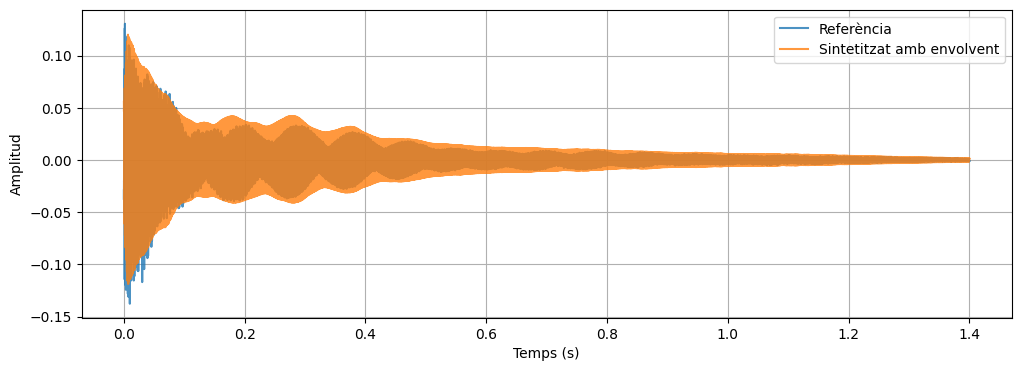

In [22]:
f0 = 904.3945   #Freqüència fonamental
phi = 0         #Fase inicial
Ak = np.array(weights)
A_ref = 0.12

t = np.arange(len(ref)) / fs

y_synt = synthesize(f0, phi, Ak, t)

y_synt_env = y_synt * env


if np.max(np.abs(y_synt_env)) > 0:
    y_synt_env = A_ref * y_synt_env / np.max(np.abs(y_synt_env))

duration = 1.4
idx_end = int(duration * fs)

plt.figure(figsize=(12,4))
plt.plot(t[:idx_end], ref[:idx_end], label='Referència', alpha=0.8)
plt.plot(t[:idx_end], y_synt_env[:idx_end], label='Sintetitzat amb envolvent', alpha=0.8)
plt.xlabel('Temps (s)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)
plt.show()

2.6. Compare the spectrograms of the reference signal and the synthesized signal. What are the main differences?

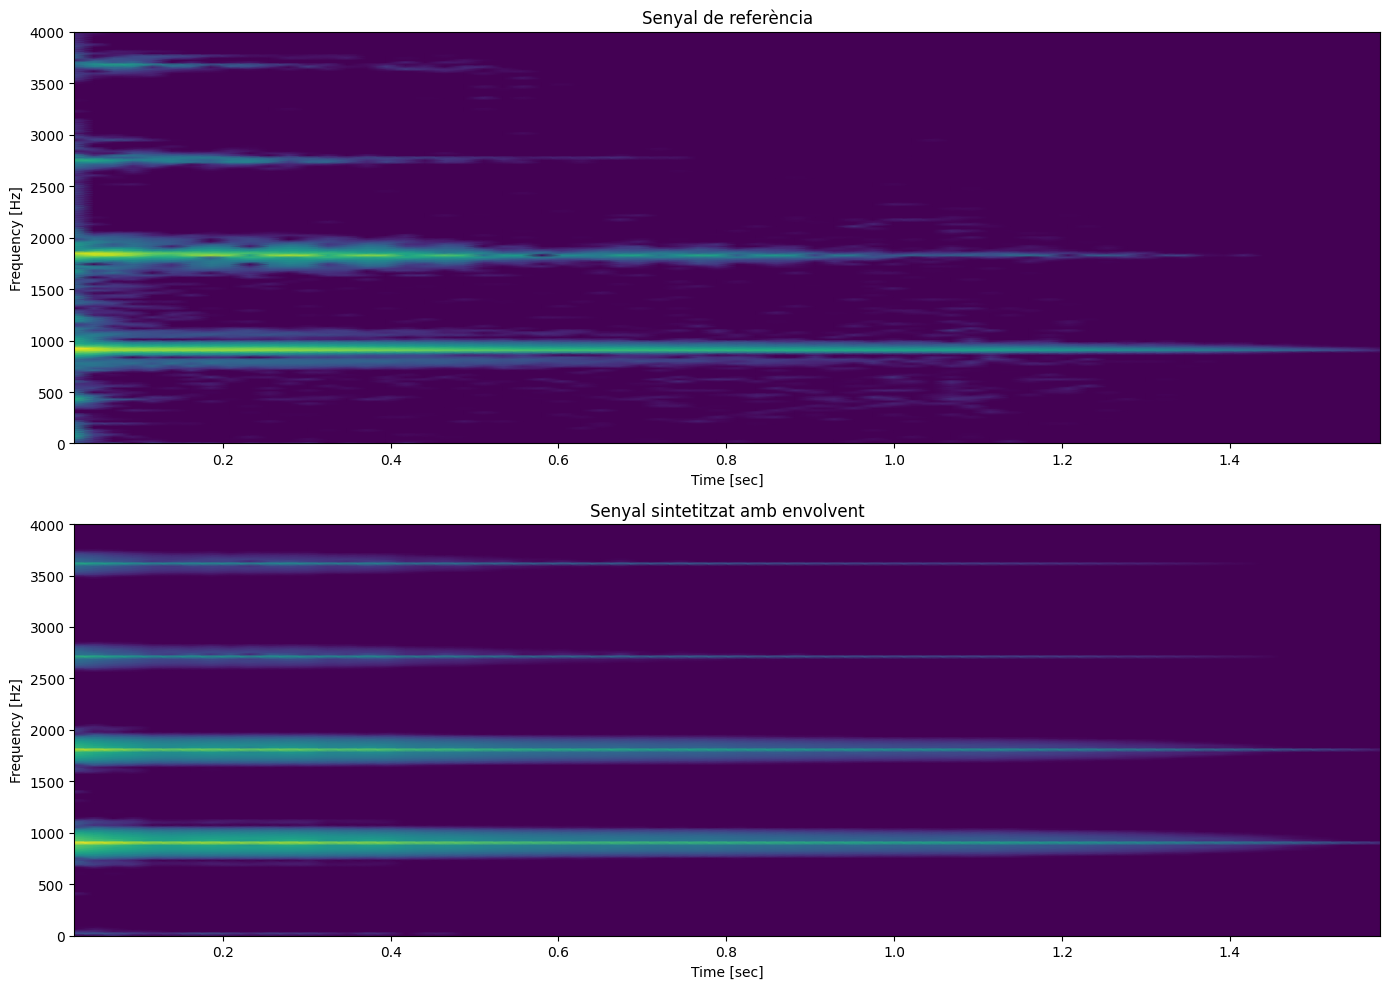

In [23]:
from scipy.signal import spectrogram

# Paràmetres
window_length = 2048

# Càlcul de l’espectrograma del senyal de referència
ff_ref, tt_ref, S_ref = spectrogram(ref, fs=fs, nperseg=window_length, noverlap=window_length/2)

# Càlcul de l’espectrograma del senyal sintetizat amb l'envolvent
ff_synt, tt_synt, S_synt = spectrogram(y_synt_env, fs=fs, nperseg=window_length, noverlap=window_length/2)

# Plot dels dos espectogrames
    # Plot de l'espectograma del senyal de referència
plt.figure(figsize=(14, 10))
plt.subplot(2, 1, 1)
plot_spectrogram(ff_ref, tt_ref, S_ref)
plt.ylim([0, 4000])
plt.title('Senyal de referència')

    # Plot del senyal sintetizat amb l'envolvent
plt.subplot(2, 1, 2)
plot_spectrogram(ff_synt, tt_synt, S_synt)
plt.ylim([0, 4000])
plt.title('Senyal sintetitzat amb envolvent')

plt.tight_layout()
plt.show()

**Una de les principals diferències en els espectogrames anteriors es deu al fet que el senyal de referència és un senyal real, per tant, en el seu espectograma podem observar més soroll, al contrari que a l'espectograma del senyal sintetitzat, el qual és molt més net i "perfecte". Tots dos tenen una evolució temporal semblant gràcies a l'envolvent que hem aplicat, tot i això, el senyal sintetitzat és més uniforme.**

2.7 Listen to the synthesized signal and compare it to the reference.



In [24]:
# Senyal de referència
print("Senyal de referència:")
display(ipd.Audio(ref, rate=fs))

# Senyal sintetitzat
print("Senyal sintetitzat amb envolvent:")
display(ipd.Audio(y_synt_env, rate=fs))

Senyal de referència:


Senyal sintetitzat amb envolvent:


**Les diferències entre els dos senyals són notables. El senyal de referència té un so molt més natural, ja que és un soroll d'una nota tocada amb una guitarra, en canvi el senyal sintetitzat és més robòtic. Tot i això, respecte a laboratoris anteriors, ja comença a ser molt més semblant al senyal original.**